# Tutorial 2.3: Simulation of Asymmetric Incomplete Registration in Human Lymph Node

This tutorial uses paired human lymph node RNA and ADT profiles to simulate asymmetric incomplete registration, in which partial spatial coverage differs between modalities. A 30% horizontal RNA-unregistered window and a spatially separated 40% ADT-unregistered window are imposed, leaving approximately 30% of locations as observed RNA-ADT anchors.

Unlike a single-target simulation, neither modality remains a global source for the other. PRISM uses the modality-specific observed regions, paired anchors and shared spatial context to impute RNA and ADT at their respective unregistered locations. The original paired profiles are retained as location-matched ground truth for both evaluations.


In [1]:
from pathlib import Path

import numpy as np
import scanpy as sc
import PRISM
from PRISM import (plot_imputation_metric_boxplot, build_modality_context_prior, compute_similarity_prior, plot_prism_imputation_spatial, preprocess_omics, prism_eval_and_save,
                   run_clustering_eval_plot, select_best_device, set_prism_plot_style, set_seed,
                   simulate_missing_sliding)
set_prism_plot_style()

In [2]:
# Load data and set up paths
DEVICE = select_best_device()
RANDOM_SEED = 2024
set_seed(RANDOM_SEED)

Slice_ID = "S1"
DATASET_DIR = Path("Datasets") / "human lymphoid organs" / "lymph" / Slice_ID
SOURCE_H5AD = DATASET_DIR / "adata_RNA.h5ad"
TARGET_H5AD = DATASET_DIR / "adata_ADT.h5ad"
RESULTS_DIR = Path("Results") / "Tutorial2_3_human_lymph_node"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_PRIOR_PATH = RESULTS_DIR / f"{Slice_ID}_lymph_RNA_AOT.npz"
TARGET_PRIOR_PATH = RESULTS_DIR / f"{Slice_ID}_lymph_ADT_AOT.npz"
RUN_PREFIX = f"{Slice_ID}_lymph_DM"

adata_source = sc.read_h5ad(SOURCE_H5AD)
adata_target = sc.read_h5ad(TARGET_H5AD)
adata_source.var_names_make_unique()
adata_target.var_names_make_unique()

### Simulating asymmetric incomplete registration

RNA and ADT are independently masked in non-overlapping horizontal windows: RNA is unavailable across the first 30% of locations (`step_id=0`), whereas a 40% ADT-unregistered window is shifted towards the opposite tissue boundary (`step_id=8`, with `lock_at_end=True`). The remaining approximately 30% of locations retain paired RNA-ADT profiles.

This asymmetric layout creates spatially separated RNA-only, ADT-only and paired regions, so neither modality is globally complete or can serve as a universal source. It therefore evaluates bidirectional PRISM-DM imputation when each modality must be predicted from its own observed locations and the shared spatial context.


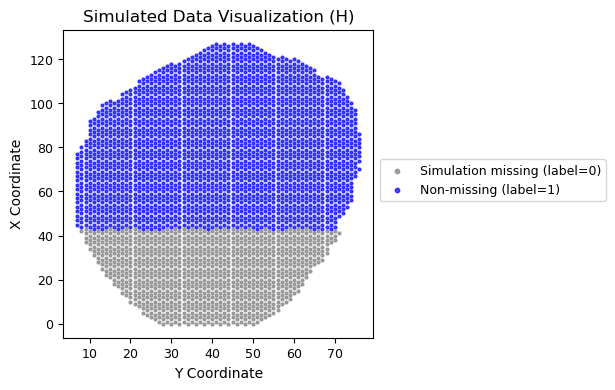

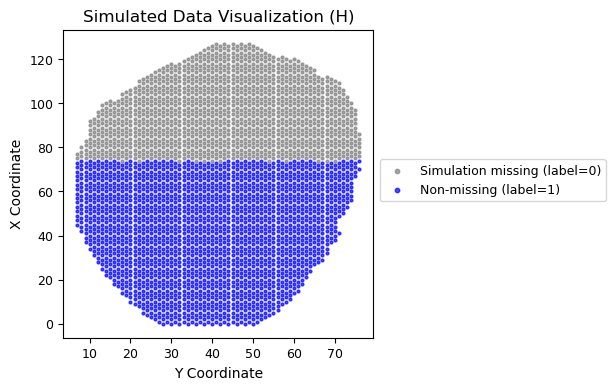

Observed in both modalities: 1046
RNA-missing only: 1045
ADT-missing only: 1393


In [3]:
source_missing_indices = simulate_missing_sliding(adata_source, spatial_key="spatial", direction="H",
                                                  missing_width=0.30, step_ratio=0.10, step_id=0,
                                                  label_key="missing", lock_at_end=True,
                                                  point_size=4, plot=True, figsize=(4, 4))

target_missing_indices = simulate_missing_sliding(adata_target, spatial_key="spatial", direction="H",
                                                  missing_width=0.40, step_ratio=0.10, step_id=8,
                                                  label_key="missing", lock_at_end=True,
                                                  point_size=4, plot=True, figsize=(4, 4))

paired_cells = adata_source.n_obs - len(source_missing_indices) - len(target_missing_indices)
print("Observed in both modalities:", paired_cells)
print("RNA-missing only:", len(source_missing_indices))
print("ADT-missing only:", len(target_missing_indices))

### Preprocessing partially observed modalities

RNA and ADT are processed with modality-specific workflows while retaining their independent availability labels. For each modality, `missing` is converted to an availability mask: unregistered rows remain at their spatial locations but are excluded as observed molecular evidence during PRISM-DM training.

In [4]:
adata_source, _ = preprocess_omics(adata_source, modality="RNA", missing_key="missing", min_cells=10,
                                   hvgs=2048, data_role="source", compute_pca=False, save_log_layer=True, 
                                   save_raw_eval=True)

adata_target, _ = preprocess_omics(adata_target, modality="ADT", missing_key="missing", data_role="target",
                                   compute_pca=False, save_log_layer=True)

print("RNA shape after preprocessing:", adata_source.shape)
print("ADT shape after preprocessing:", adata_target.shape)

RNA shape after preprocessing: (3484, 2048)
ADT shape after preprocessing: (3484, 31)


### Constructing modality-specific priors and context

RNA and ADT are unavailable in different tissue regions, so a missing-aware similarity prior is constructed independently from the observed locations of each modality. `context_prior` combines these two priors into the availability-aware context supplied to PRISM-DM for joint training.

This provides the shared spatial context needed to impute RNA and ADT at their respective unregistered locations.


In [5]:
# Compute RNA and ADT priors from modality-specific observed profiles
source_distance, source_prior_metrics = compute_similarity_prior(adata_source, adata_target, SOURCE_PRIOR_PATH, 
                                                                 device=DEVICE, covet_k_spatial=6, covet_gene_num=64,
                                                                 spatial_key="spatial", missing_key="missing")

target_distance, target_prior_metrics = compute_similarity_prior(adata_target, adata_source, TARGET_PRIOR_PATH, 
                                                                 device=DEVICE, covet_k_spatial=6, covet_gene_num=None,
                                                                 spatial_key="spatial", missing_key="missing")

Step 1: src COVET
Using the top 64 genes from the pre-calculated HVG ranking for COVET
Computing COVET using 64 genes
Using expression data from layer 'log'
Calculating covariance matrices for all cells/spots
Computing matrix square root.
[COVET | auto missing-aware mode]
Original n_obs : 3484
Reference n_obs: 2439
has missing    : True
missing cells  : 1045
observed cells : 2439
k_spatial used     : 6
batch_key used     : -1
COVET shape        : (2439, 64, 64)
COVET_SQRT shape   : (2439, 64, 64)
Number of CovGenes : 64

Step 2: src AOT
[AOT] representation=full COVET_SQRT flatten
[AOT] n=2439, d=4096, k_env=2438, backend=torch
[AOT] distances stored are squared Euclidean/Frobenius distances.
[AOT/torch] device=cuda:1
[AOT/torch] processed 2439/2439
[AOT] saved adata.obsp['aot_distances_ref'] shape=(2439, 2439), nnz=5946282
[AOT | auto missing-aware mode]
Reference AOT shape      : (2439, 2439)
Reference AOT nnz        : 5946282
Original-space AOT shape : (3484, 3484)
Original-space AO

Step 1: src COVET
Computing COVET using all 31 genes
Using expression data from layer 'log'
Calculating covariance matrices for all cells/spots
Computing matrix square root.
[COVET | auto missing-aware mode]
Original n_obs : 3484
Reference n_obs: 2091
has missing    : True
missing cells  : 1393
observed cells : 2091
k_spatial used     : 6
batch_key used     : -1
COVET shape        : (2091, 31, 31)
COVET_SQRT shape   : (2091, 31, 31)
Number of CovGenes : 31

Step 2: src AOT
[AOT] representation=full COVET_SQRT flatten
[AOT] n=2091, d=961, k_env=2090, backend=torch
[AOT] distances stored are squared Euclidean/Frobenius distances.
[AOT/torch] device=cuda:1
[AOT/torch] processed 2091/2091
[AOT] saved adata.obsp['aot_distances_ref'] shape=(2091, 2091), nnz=4370190
[AOT | auto missing-aware mode]
Reference AOT shape      : (2091, 2091)
Reference AOT nnz        : 4370190
Original-space AOT shape : (3484, 3484)
Original-space AOT nnz   : 4370190
k_env used               : 2090
AOT feature shap

In [6]:
# Combine both priors into availability-compatible context references
context_prior = build_modality_context_prior(adata_source, adata_target,
                                                  source_distance=source_distance,
                                                  target_distance=target_distance,
                                                  missing_key="missing", allow_both_missing=False, 
                                                  check_examples=True)

source prior: (3484, 3484) nnz: 5946282
target prior: (3484, 3484) nnz: 4370190
pair: 1046
src_only: 1393
tgt_only: 1045
both_missing: 0
src observed: 2439
tgt observed: 2091
source context complete top-k: 3484 / 3484
target context complete top-k: 3484 / 3484
source context prior source counts: {'src': 2439, 'tgt': 1045}
source context candidate pool counts: {'pair': 1045, 'src_obs': 2439}
target context prior source counts: {'src': 1393, 'tgt': 2091}
target context candidate pool counts: {'pair': 1393, 'tgt_obs': 2091}

===== check row 0 s1-AACACTTGGCAAGGAA-1 =====
src observed: True
tgt observed: True
src self missing: False
tgt self missing: False

source context:
  prior source: src
  candidate pool: src_obs
  top-k global: [1623 3155 1823  754 3051 2151  120 2781  104 2246]
  top-k dist: [24.11787  30.943295 38.420002 38.687004 41.126698 41.297585 42.17125
 44.14488  45.21281  47.66105 ]
  neighbor obs_names: ['s1-CTGAAGGTGCTCGAGG-1', 's1-TCTACTCCGACTCGGC-1', 's1-GACGCAGCGTCAAGTT

------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.


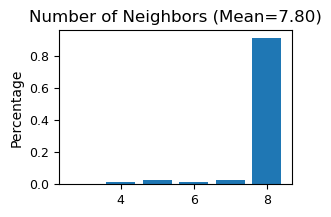

------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.


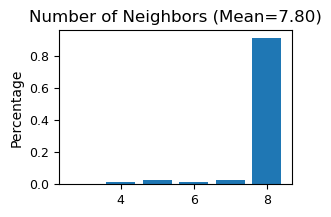

In [7]:
# Constructing spatial graphs
PRISM.Cal_Spatial_Net(adata_source, rad_cutoff=2.0)
PRISM.Stats_Spatial_Net(adata_source)
PRISM.Cal_Spatial_Net(adata_target, rad_cutoff=2.0)
PRISM.Stats_Spatial_Net(adata_target)

### Training PRISM-DM

PRISM-DM jointly learns from the two partially observed modalities using their spatial graphs and `context_prior`. `missing` identifies RNA- and ADT-unregistered locations; these profiles are represented as learnable imputation tokens, allowing the remaining RNA-only, ADT-only and paired locations to inform both modalities.

The trained objects provide `PRISM_emb` for spatial-domain analysis and modality-specific predictions for RNA and ADT imputation.


In [ ]:
# Train PRISM-DM on the full graph
adata_source_out, adata_target_out = PRISM.train_PRISM_DM(adata_source, adata_target, context_prior, 
                                                          k_top=5, n_epochs=1000, lr=1e-3, output_dir=str(RESULTS_DIR),
                                                          file_prefix=RUN_PREFIX, device=DEVICE, patience=20, 
                                                          min_epochs=50, center_drop_rate=0.1, noise=0.0, 
                                                          load_model_path=False, interaction_pca=False)


>>> Early stopping at epoch 424.
Best model saved: Results/Tutorial2_3_human_lymph_node/S1_lymph_DM_model.pth
Finished training and deterministic inference: S1_lymph_DM


### Task 1: Spatial-domain identification

Task 1 clusters `PRISM_emb`, the joint representation learned from the complementary partially observed RNA and ADT data, to identify lymph node spatial domains. Agreement with the reference annotation is summarized using AMI, V-measure, mutual information, homogeneity, NMI and ARI.

Domain clustering metrics: {'embedding': 'PRISM_emb', 'cluster_key': 'PRISM_DM_mclust', 'AMI': 0.3363, 'V_measure': 0.3406, 'Mutual_info': 0.6425, 'Homogeneity': 0.3719, 'NMI': 0.3406, 'ARI': 0.2038}


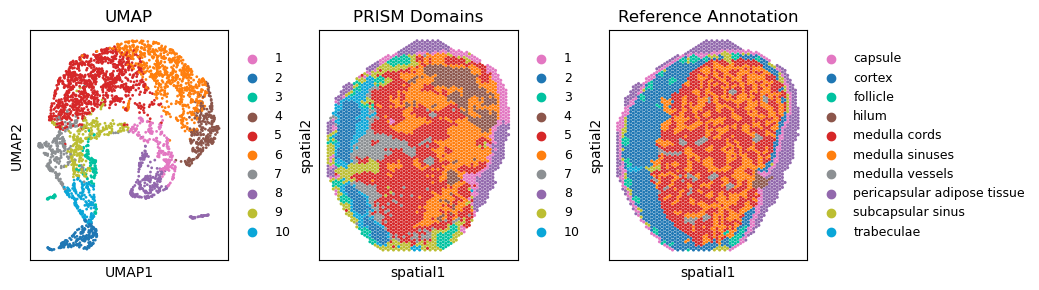

In [53]:
# Cluster the joint PRISM embedding and evaluate spatial-domain agreement
adata_clustered, domain_metrics = run_clustering_eval_plot(adata_source_out, emb_key="PRISM_emb", label_key="final_annot",
                                                           cluster_key="PRISM_DM_mclust", n_clusters=10, s=20, use_pca=True,
                                                           align_labels=True, aligned_key="PRISM_DM_mclust_domain",
                                                           dataset_name="lymph")

### Task 2: RNA and ADT imputation

Task 2 evaluates RNA and ADT imputation at their separately simulated unregistered windows. The paired pre-masking profiles provide location-matched raw-scale ground truth for both modalities. RNA performance is evaluated across the 800 highly variable genes selected during preprocessing and ADT performance across proteins.

Overall performance is summarized as the mean +/- s.d. of feature-wise Pearson correlation coefficient (PCC), Spearman correlation coefficient (SPCC) and mean squared error (MSE). The representative spatial plots below compare individual RNA and ADT features with their imputed patterns.


Imputation metrics (mean +/- s.d.): PCC=0.2920 +/- 0.2279, SPCC=0.2444 +/- 0.1855, MSE=0.0326 +/- 0.0138
Missing observations: 1045


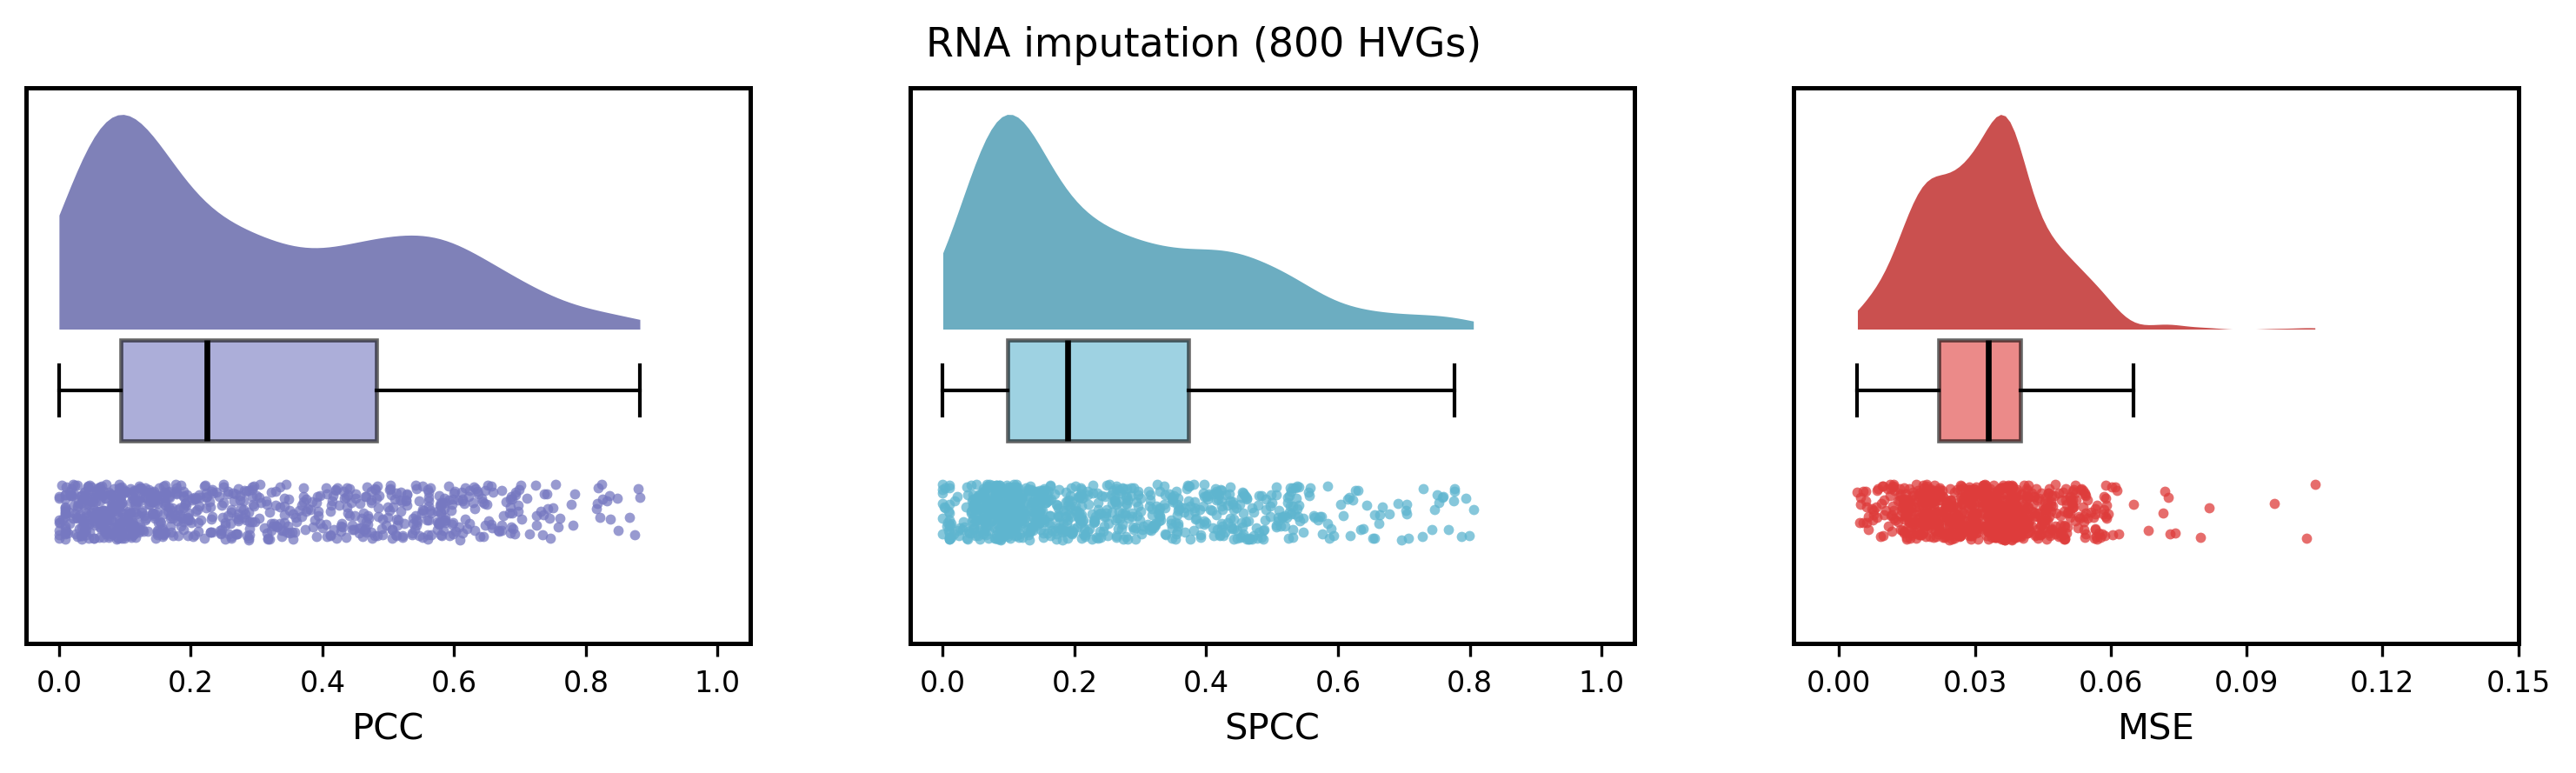

In [71]:
# Evaluate RNA imputation at RNA-unregistered locations
rna_imputation_results = prism_eval_and_save(truth_adata=adata_source_out, adata=adata_source_out,
                                             prediction_key="PRISM_src_pred", save_path=str(RESULTS_DIR), 
                                             first_name=RUN_PREFIX, missing_indices=source_missing_indices,
                                             output_suffix="RNA", save_files=False, topk_features=800, 
                                             topk_rank_by="var_order", topk_only=True, save_topk_summary=True)

_ = plot_imputation_metric_boxplot(rna_imputation_results, feature_names=adata_source.var_names,
                                   feature_label="RNA gene", output_suffix="RNA", plot_type="raincloud")

Imputation metrics (mean +/- s.d.): PCC=0.5924 +/- 0.2017, SPCC=0.5914 +/- 0.1679, MSE=0.0331 +/- 0.0317
Missing observations: 1393


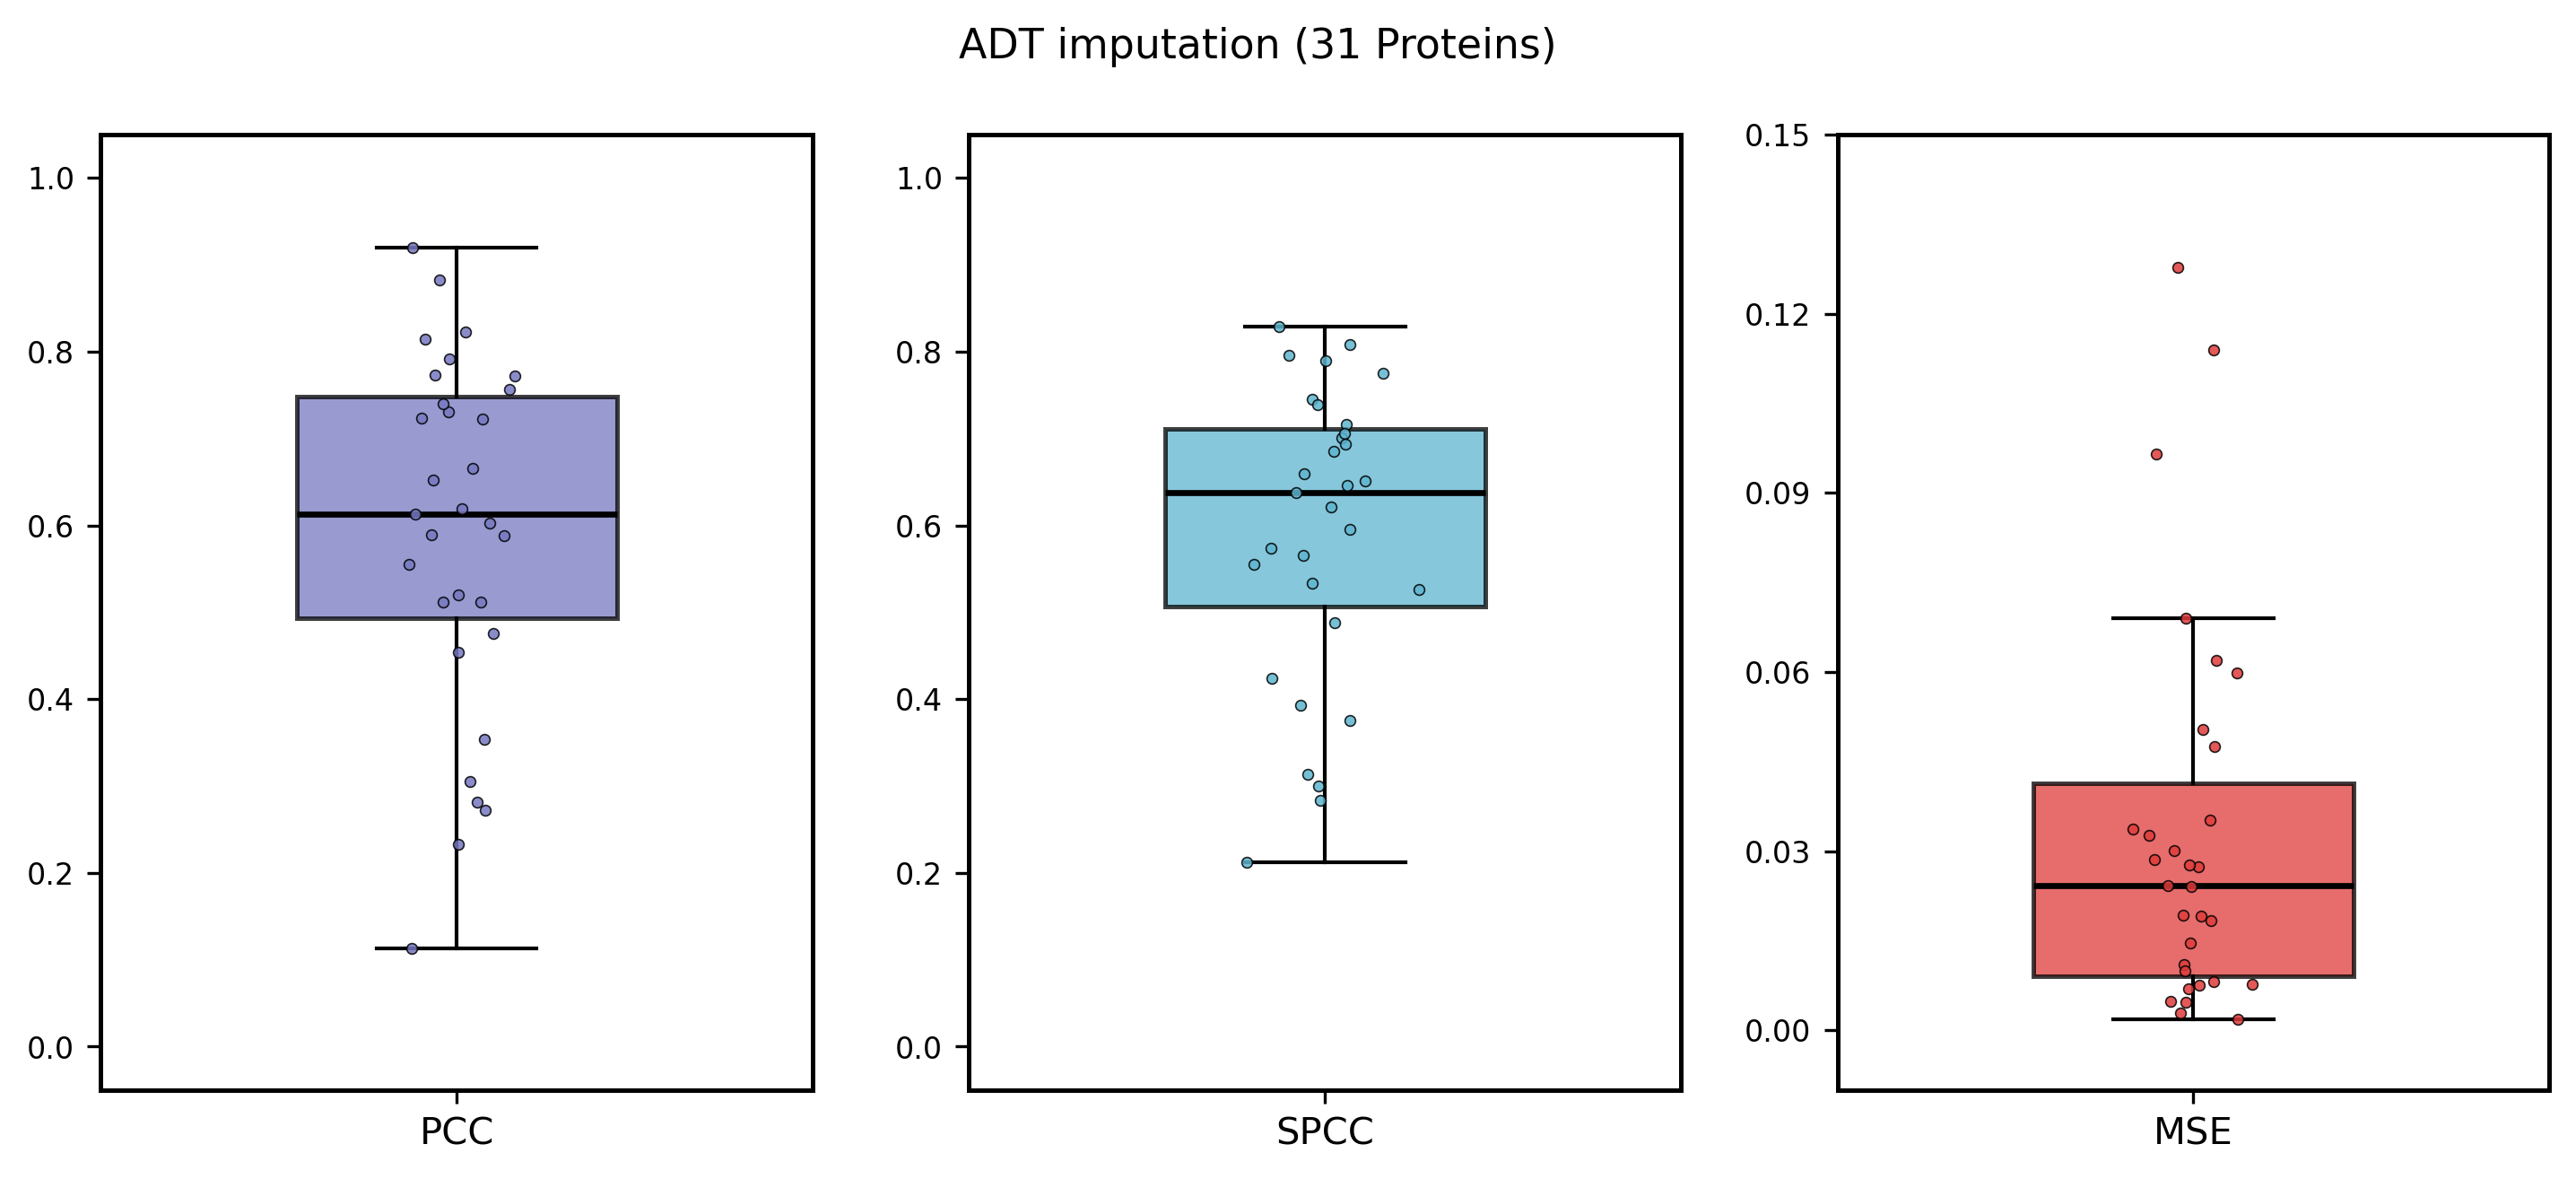

In [20]:
# Evaluate ADT imputation at ADT-unregistered locations
adt_imputation_results = prism_eval_and_save(truth_adata=adata_target_out, adata=adata_target_out,
                                             prediction_key="PRISM_tgt_pred", save_path=str(RESULTS_DIR),
                                             first_name=RUN_PREFIX, missing_indices=target_missing_indices,
                                             output_suffix="ADT", save_files=False)

_ = plot_imputation_metric_boxplot(adt_imputation_results, feature_names=adata_target.var_names,
                                   feature_label="ADT protein", output_suffix="ADT", plot_type="boxplot")

Representative RNA gene LTB: {'PCC': 0.882, 'SPCC': 0.8055, 'MSE': 0.0045}


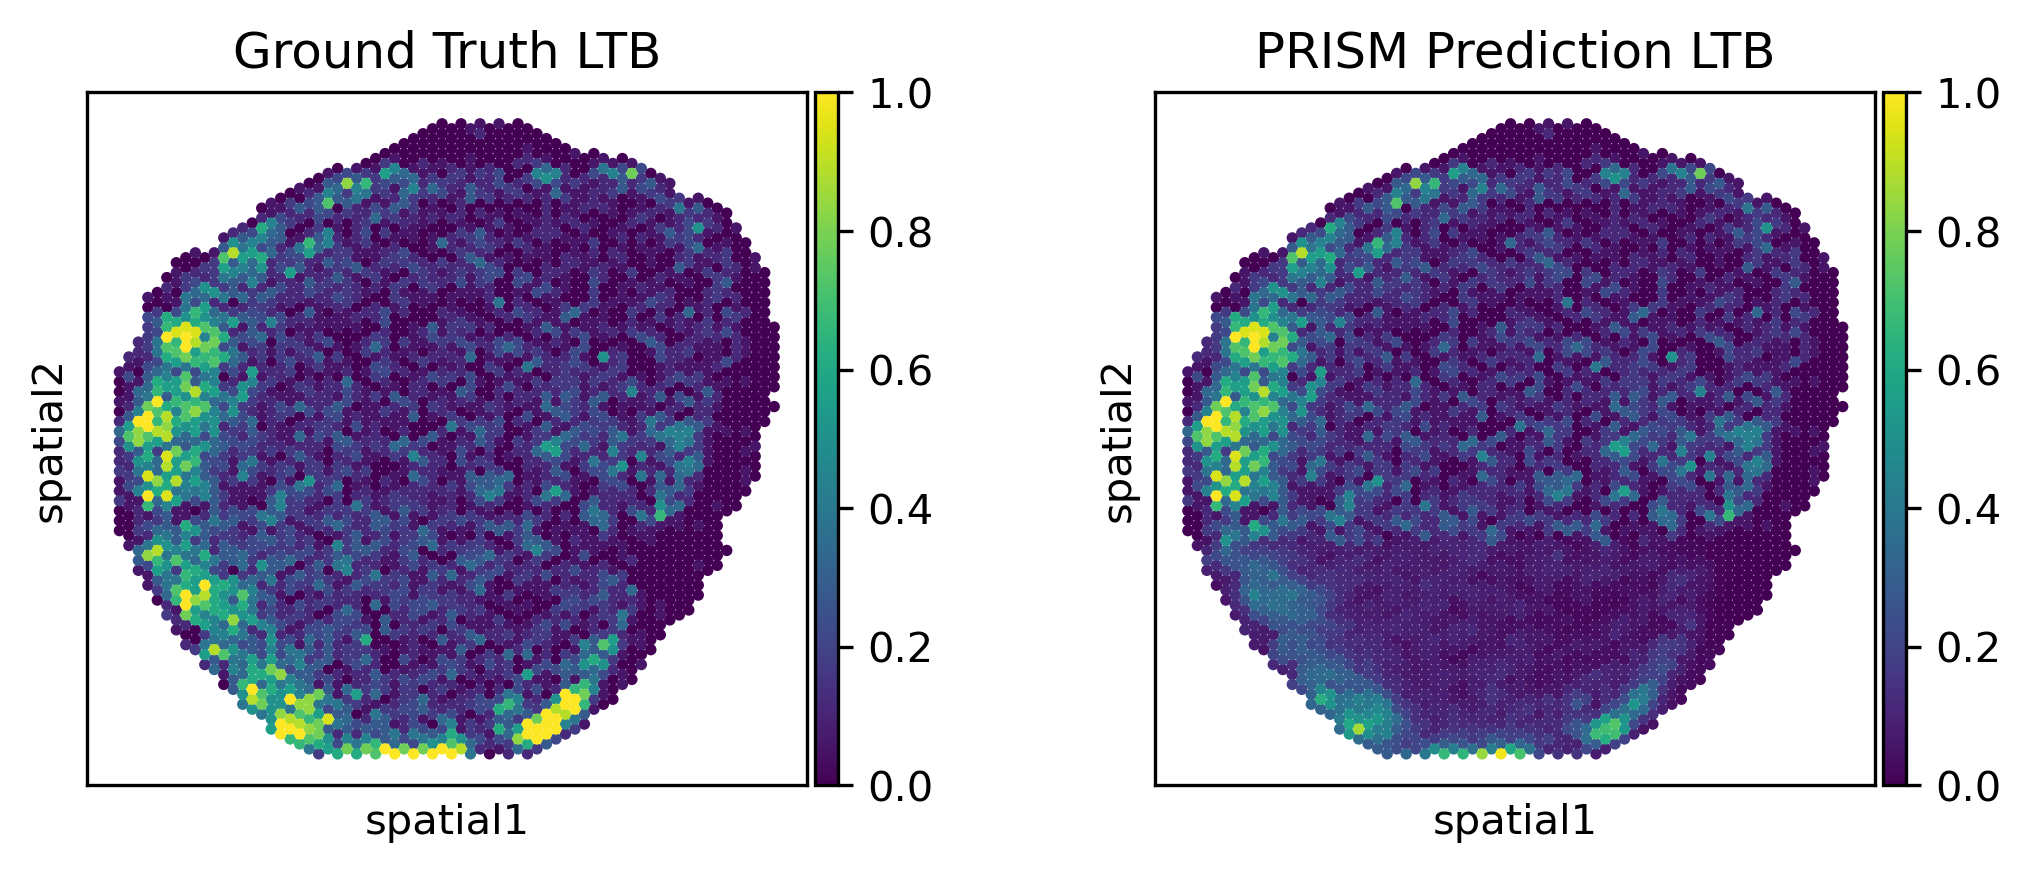

In [72]:
# Visualize a representative RNA gene imputation
RNA_FEATURE_TO_PLOT = "LTB"

fig, axs = plot_prism_imputation_spatial(imputation_results=rna_imputation_results, split1_indices=source_missing_indices,
                                         feature=RNA_FEATURE_TO_PLOT, point_size=30, show_missing_only=False, highlight_missing=False,
                                         figsize=(8, 3))

feature_idx = adata_source.var_names.get_loc(RNA_FEATURE_TO_PLOT)
feature_metrics = {metric: round(float(rna_imputation_results["raw"]["per_protein"][metric][feature_idx]), 4)
                   for metric in ("PCC", "SPCC", "MSE")}
print(f"Representative RNA gene {RNA_FEATURE_TO_PLOT}: {feature_metrics}")

Representative ADT protein CD3E: {'PCC': 0.8824, 'SPCC': 0.8284, 'MSE': 0.0046}


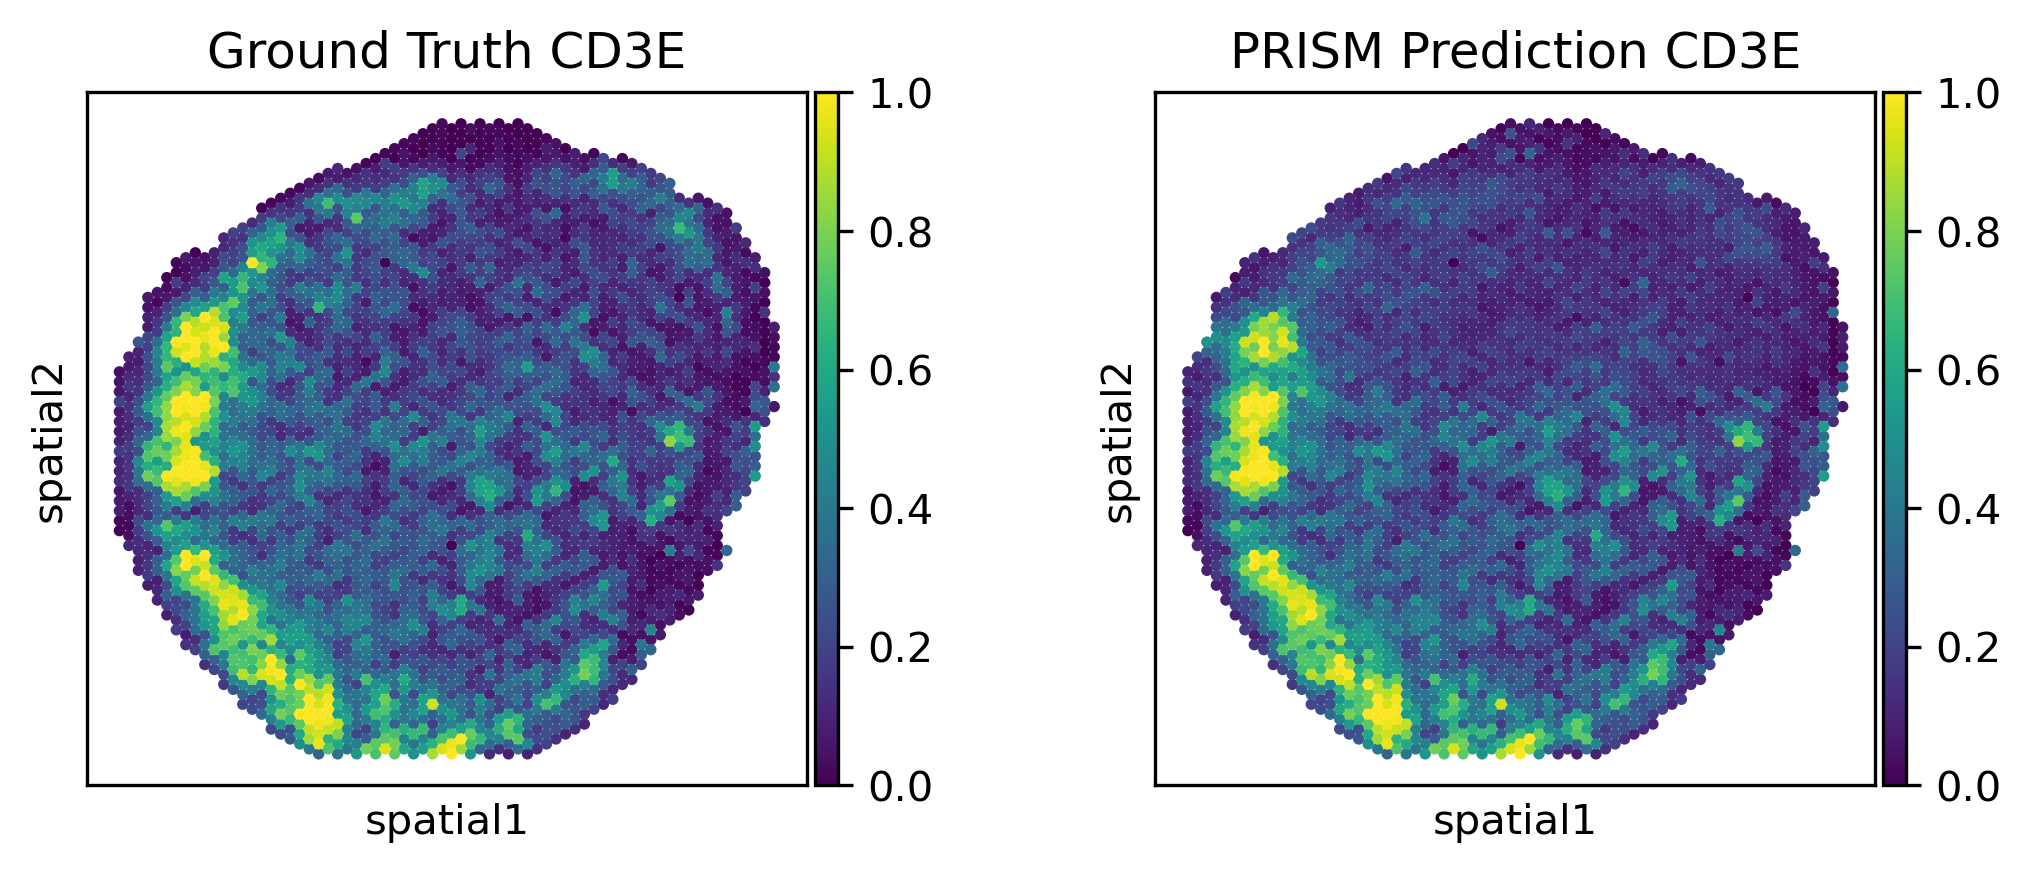

In [73]:
# Visualize a representative ADT protein imputation
ADT_FEATURE_TO_PLOT = "CD3E"
fig, axs = plot_prism_imputation_spatial(imputation_results=adt_imputation_results, split1_indices=target_missing_indices,
                                         feature=ADT_FEATURE_TO_PLOT, point_size=30, show_missing_only=False, highlight_missing=False,
                                         figsize=(8, 3))

feature_idx = adata_target.var_names.get_loc(ADT_FEATURE_TO_PLOT)
feature_metrics = {metric: round(float(adt_imputation_results["raw"]["per_protein"][metric][feature_idx]), 4)
                   for metric in ("PCC", "SPCC", "MSE")}
print(f"Representative ADT protein {ADT_FEATURE_TO_PLOT}: {feature_metrics}")